In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional,  LSTM, Dense, Dropout

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


In [29]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion", "split")

In [30]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


In [31]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

(16000, 2)
(2000, 2)


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


In [32]:
emotion_names = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [33]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])

In [34]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")

tokenizer.fit_on_texts(train_df["text"])

In [35]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
X_test = tokenizer.texts_to_sequences(test_df["text"])

In [36]:
max_length = 40

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")

In [37]:
model = Sequential()

model.add(
    Embedding(input_dim=vocab_size,
              output_dim=64,
              input_length=max_length)
)

model.add(
    Bidirectional(LSTM(64))
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(64, activation="relu")
)

model.add(
    Dense(6, activation="softmax")
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [40]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3955 - loss: 1.5060 - val_accuracy: 0.6056 - val_loss: 1.0749
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7405 - loss: 0.7112 - val_accuracy: 0.8069 - val_loss: 0.5691
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8734 - loss: 0.3727 - val_accuracy: 0.8481 - val_loss: 0.4388
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9229 - loss: 0.2360 - val_accuracy: 0.8594 - val_loss: 0.4326
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9414 - loss: 0.1691 - val_accuracy: 0.8650 - val_loss: 0.4702
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9578 - loss: 0.1320 - val_accuracy: 0.8763 - val_loss: 0.4604
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9680 - loss: 0.1017 - val_accuracy: 0.8703 - val_loss: 0.4844


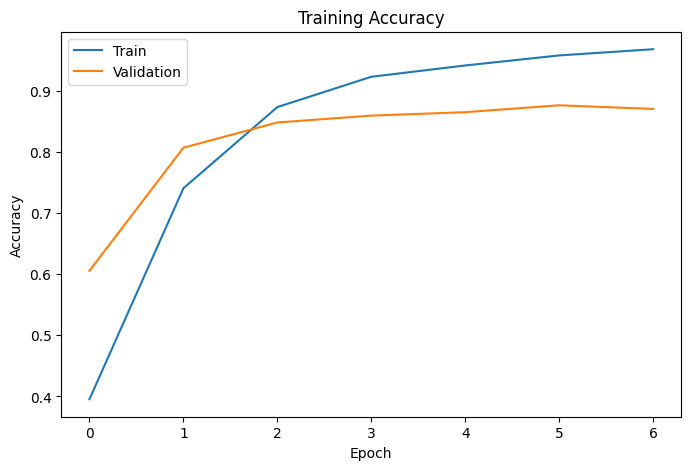

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

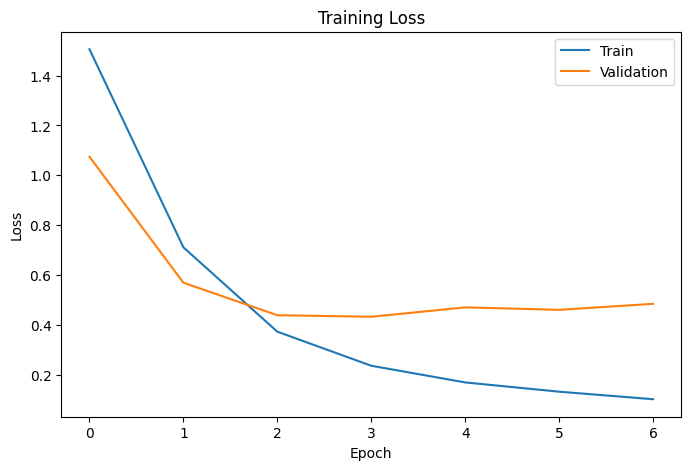

In [42]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()


In [43]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8570 - loss: 0.4642
Test Accuracy : 0.8569999933242798


In [44]:
sentence = ["I want to enjoy"]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
Predicted Emotion: joy


In [45]:
sentence = ["I am exicited about tomorrow's class"]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Emotion: joy
